<a href="https://colab.research.google.com/github/adeniranlj-ui/projects1/blob/main/Hit_song_Ai_Analsysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
### This project works to analsyis a dataset from kaggle that already measures song succes(hit or miss) then trains an ai
#### to reach the same conclusion so that buisnesses can PREDICT whether or NOT a song is succesful BEFORE releasing to the public.

In [ ]:
from google.colab import files
import pandas as pd
import os

# Upload the balanced CSV file (train_balanced.csv)
uploaded = files.upload()
print(os.listdir())

df = pd.read_csv(list(uploaded.keys())[0])
print(f'Dataset shape: {df.shape}')
df.head()

Saving train_balanced.csv to train_balanced.csv
['.config', 'train_balanced.csv', 'FinalMLproj (1).ipynb', 'sample_data']
Dataset shape: (29644, 22)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,hit
0,20411,6kex4EBAj0WHXDKZMEJaaF,Jason Derulo;Nicki Minaj;Ty Dolla $ign,Swalla (feat. Nicki Minaj & Ty Dolla $ign),Swalla (feat. Nicki Minaj & Ty Dolla $ign),76,216408,True,0.696,0.817,...,1,0.1090,0.075000,0.000000,0.187,0.782,98.064,4,dance,1
1,69736,1meF9wzOquLL3GYx9Rg9ED,Sujatha,Karyam Nissaram,Kanmani Ponmaniye,21,239986,False,0.548,0.188,...,0,0.0501,0.953000,0.004590,0.127,0.817,150.548,3,malay,0
2,110196,34L980Ez8bi6da2zlj7j92,Mandragora,"Sound of Deep-House, Vol. 1",Enjoy the Greatness - Club Mix,0,197520,False,0.659,0.842,...,1,0.0462,0.000088,0.506000,0.367,0.131,119.040,4,trance,0
3,60498,04xiGpWe8h7096PLVjirf1,Ryuji Imaichi,LIGHT>DARKNESS,THROWBACK,22,188506,False,0.624,0.920,...,1,0.0741,0.043900,0.000000,0.740,0.840,104.876,4,j-dance,0
4,31029,3LlmKSHR3Rs0Y3KHQLAYDk,Alan Walker,Different World,Alone,74,160426,False,0.673,0.914,...,1,0.0496,0.229000,0.000478,0.186,0.183,97.021,4,electro,1


In [ ]:
# Drop identifier columns and popularity (data leakage)
df = df.drop(columns=[
    col for col in [
        'Unnamed: 0',
        'track_id',
        'artists',
        'album_name',
        'track_name',
        'popularity'
    ] if col in df.columns
])

print('Remaining columns:', df.columns.tolist())

Remaining columns: ['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre', 'hit']


In [ ]:
# The dataset is pre-balanced — verify this is correct
print('Absolute counts:')
print(df['hit'].value_counts())
print()
print('Proportions:')
print(df['hit'].value_counts(normalize=True).round(3))

Absolute counts:
hit
1    14822
0    14822
Name: count, dtype: int64

Proportions:
hit
1    0.5
0    0.5
Name: proportion, dtype: float64


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Models cannot read text so we convert genre to integers
# Keep original column for genre analysis later
df['track_genre_encoded'] = le.fit_transform(df['track_genre'])

print('Genres encoded. Example mapping:')
for genre, code in zip(le.classes_[:5], range(5)):
    print(f'  {genre} -> {code}')

Genres encoded. Example mapping:
  acoustic -> 0
  afrobeat -> 1
  alt-rock -> 2
  alternative -> 3
  ambient -> 4


In [ ]:
X = df.drop(columns=['hit', 'track_genre'])
y = df['hit']

print('Feature columns:', X.columns.tolist())
print(f'Total samples: {len(X)}')
print(f'Hits: {y.sum()} | Non-hits: {(y == 0).sum()}')

Feature columns: ['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre_encoded']
Total samples: 29644
Hits: 14822 | Non-hits: 14822


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
# stratify=y preserves the 50/50 hit ratio in both train and test sets
print(f'Training set: {len(X_train)} samples')
print(f'Test set:     {len(X_test)} samples')
print(f'Train hits: {y_train.sum()} | Train non-hits: {(y_train == 0).sum()}')

Training set: 20750 samples
Test set:     8894 samples
Train hits: 10375 | Train non-hits: 10375


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data only, then transform both sets
# This prevents test data from influencing the scaling
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# class_weight='balanced' gives extra penalty for misclassifying hits
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train_scaled, y_train)

# Lower threshold to 0.3 so model is more willing to call something a hit
log_proba = log_model.predict_proba(X_test_scaled)[:, 1]
log_pred  = (log_proba >= 0.3).astype(int)

print('=== Logistic Regression ===')
print('Accuracy:', round(accuracy_score(y_test, log_pred), 4))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, log_pred))
print('\nClassification Report:')
print(classification_report(y_test, log_pred))

=== Logistic Regression ===
Accuracy: 0.5558

Confusion Matrix:
[[ 730 3717]
 [ 234 4213]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.16      0.27      4447
           1       0.53      0.95      0.68      4447

    accuracy                           0.56      8894
   macro avg       0.64      0.56      0.48      8894
weighted avg       0.64      0.56      0.48      8894



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# class_weight='balanced' ensures hits and non-hits contribute equally
tree_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
tree_model.fit(X_train, y_train)

# Lower threshold to catch more hits
tree_proba = tree_model.predict_proba(X_test)[:, 1]
tree_pred  = (tree_proba >= 0.3).astype(int)

print('=== Decision Tree ===')
print('Accuracy:', round(accuracy_score(y_test, tree_pred), 4))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, tree_pred))
print('\nClassification Report:')
print(classification_report(y_test, tree_pred))

=== Decision Tree ===
Accuracy: 0.6933

Confusion Matrix:
[[2985 1462]
 [1266 3181]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.67      0.69      4447
           1       0.69      0.72      0.70      4447

    accuracy                           0.69      8894
   macro avg       0.69      0.69      0.69      8894
weighted avg       0.69      0.69      0.69      8894



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# KNN does not support class_weight so we rely on the balanced dataset
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Lower threshold to 0.3
knn_proba = knn_model.predict_proba(X_test_scaled)[:, 1]
knn_pred  = (knn_proba >= 0.3).astype(int)

print('=== KNN ===')
print('Accuracy:', round(accuracy_score(y_test, knn_pred), 4))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, knn_pred))
print('\nClassification Report:')
print(classification_report(y_test, knn_pred))

=== KNN ===
Accuracy: 0.6211

Confusion Matrix:
[[1523 2924]
 [ 446 4001]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.34      0.47      4447
           1       0.58      0.90      0.70      4447

    accuracy                           0.62      8894
   macro avg       0.68      0.62      0.59      8894
weighted avg       0.68      0.62      0.59      8894



In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# MLPClassifier does not support sample_weight
# The balanced dataset handles class imbalance instead
nn_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
nn_model.fit(X_train_scaled, y_train)

# Lower threshold to 0.3
nn_proba = nn_model.predict_proba(X_test_scaled)[:, 1]
nn_pred  = (nn_proba >= 0.3).astype(int)

print('=== Neural Network ===')
print('Accuracy:', round(accuracy_score(y_test, nn_pred), 4))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, nn_pred))
print('\nClassification Report:')
print(classification_report(y_test, nn_pred))

=== Neural Network ===
Accuracy: 0.6449

Confusion Matrix:
[[2028 2419]
 [ 739 3708]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.46      0.56      4447
           1       0.61      0.83      0.70      4447

    accuracy                           0.64      8894
   macro avg       0.67      0.64      0.63      8894
weighted avg       0.67      0.64      0.63      8894



In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'KNN', 'Neural Network'],
    'Accuracy': [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, nn_pred),
    ],
    'F1 (macro)': [
        f1_score(y_test, log_pred, average='macro'),
        f1_score(y_test, tree_pred, average='macro'),
        f1_score(y_test, knn_pred, average='macro'),
        f1_score(y_test, nn_pred, average='macro'),
    ]
})

results = results.sort_values(by='F1 (macro)', ascending=False).reset_index(drop=True)
results['Accuracy']   = results['Accuracy'].round(4)
results['F1 (macro)'] = results['F1 (macro)'].round(4)
results

,Model,Accuracy,F1 (macro)
0,Decision Tree,0.6933,0.6931
1,Neural Network,0.6449,0.6318
2,KNN,0.6211,0.5892
3,Logistic Regression,0.5558,0.4753


=== Decision Tree — Feature Importances ===
track_genre_encoded    0.192933
duration_ms            0.086442
loudness               0.083462
instrumentalness       0.080232
liveness               0.076041
energy                 0.076017
valence                0.075253
speechiness            0.074293
danceability           0.069541
acousticness           0.068009
tempo                  0.065524
key                    0.034419
explicit               0.007847
mode                   0.006985
time_signature         0.003003


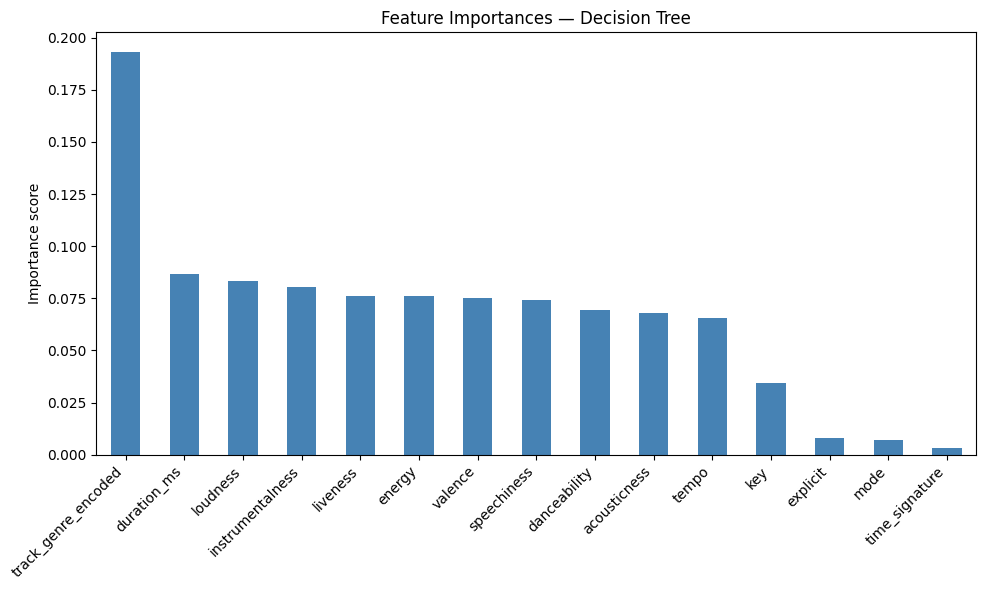


=== Logistic Regression — Coefficients ===
(positive = hit indicator, negative = non-hit indicator)
explicit               0.169365
danceability           0.084138
time_signature         0.048539
track_genre_encoded    0.026602
loudness               0.022027
key                    0.007767
mode                  -0.051254
tempo                 -0.071153
valence               -0.108413
duration_ms           -0.120299
speechiness           -0.169363
energy                -0.211848
liveness              -0.233635
acousticness          -0.271073
instrumentalness      -0.401547


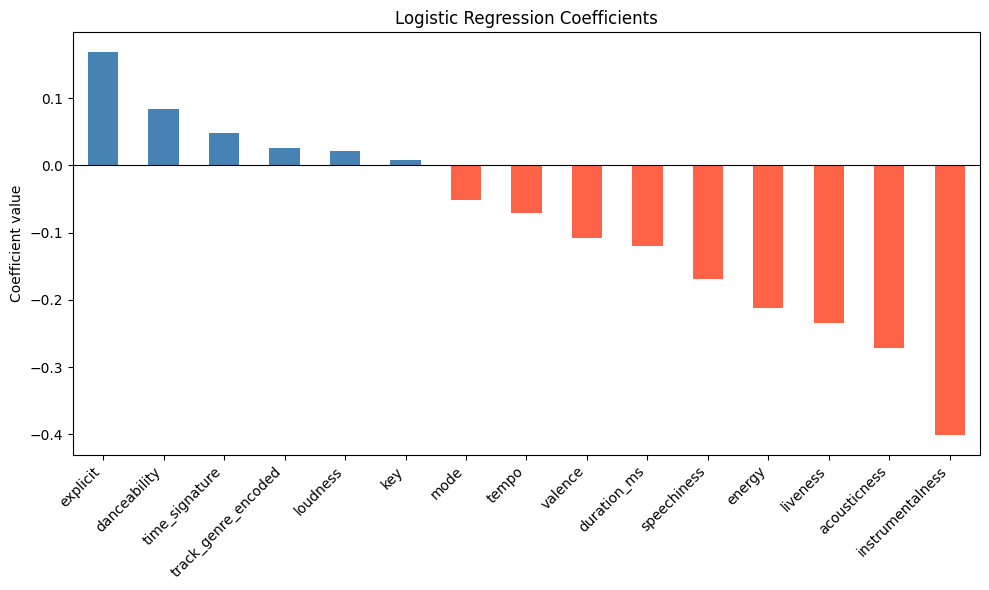

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Decision Tree feature importances ────────────────────────────────────────
feat_imp = pd.Series(
    tree_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("=== Decision Tree — Feature Importances ===")
print(feat_imp.to_string())

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar', color='steelblue')
plt.title("Feature Importances — Decision Tree")
plt.ylabel("Importance score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ── Logistic Regression coefficients ─────────────────────────────────────────
# Positive coefficient → feature pushes toward hit (1)
# Negative coefficient → feature pushes toward non-hit (0)
log_coef = pd.Series(
    log_model.coef_[0],
    index=X.columns
).sort_values(ascending=False)

print("\n=== Logistic Regression — Coefficients ===")
print("(positive = hit indicator, negative = non-hit indicator)")
print(log_coef.to_string())

plt.figure(figsize=(10, 6))
colors = ['steelblue' if c >= 0 else 'tomato' for c in log_coef]
log_coef.plot(kind='bar', color=colors)
plt.title("Logistic Regression Coefficients")
plt.ylabel("Coefficient value")
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

=== Mean Feature Values: Hits vs Non-Hits ===
                        Hit mean  Non-hit mean  Difference
loudness                 -7.4985       -8.3581      0.8596
track_genre_encoded      56.9595       56.2768      0.6827
key                       5.3564        5.2973      0.0590
explicit                  0.1293        0.0754      0.0538
time_signature            3.9358        3.8947      0.0411
danceability              0.5945        0.5627      0.0318
valence                   0.4824        0.4711      0.0113
energy                    0.6462        0.6425      0.0037
speechiness               0.0762        0.0862     -0.0099
mode                      0.6104        0.6449     -0.0345
liveness                  0.1800        0.2185     -0.0385
acousticness              0.2682        0.3210     -0.0529
instrumentalness          0.0726        0.1719     -0.0993
tempo                   120.7126      122.6947     -1.9821
duration_ms          218799.1785   229252.2776 -10453.0991


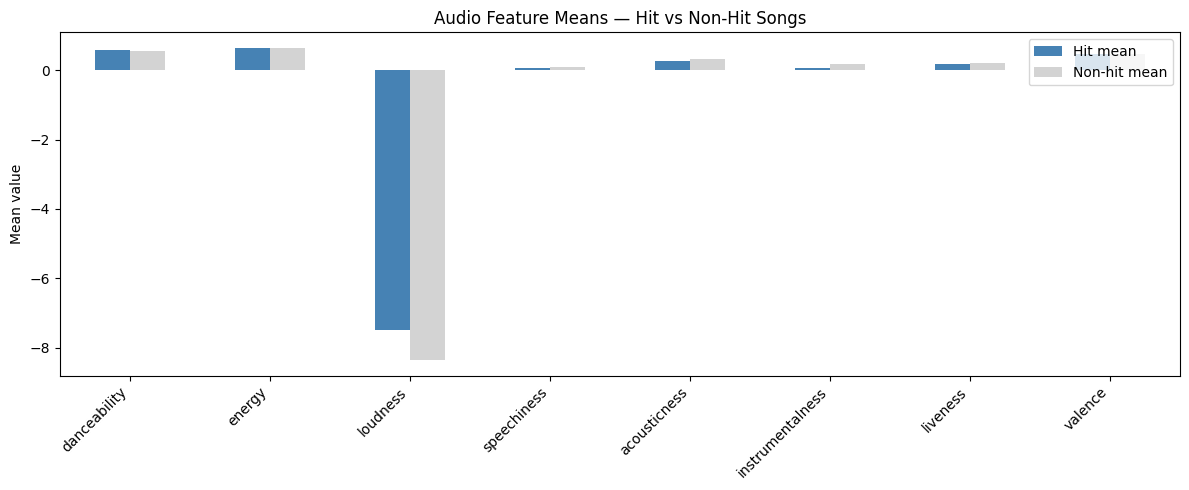

In [ ]:
# ── Hit vs Non-Hit mean feature comparison ───────────────────────────────────
hit_means     = X[y == 1].mean()
non_hit_means = X[y == 0].mean()

comparison = pd.DataFrame({
    'Hit mean'    : hit_means,
    'Non-hit mean': non_hit_means,
    'Difference'  : hit_means - non_hit_means,
}).sort_values('Difference', ascending=False)

print("=== Mean Feature Values: Hits vs Non-Hits ===")
print(comparison.round(4).to_string())

# Visualise the differences for the most interpretable audio features
audio_feats = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence'
]
comp_audio = comparison.loc[audio_feats, ['Hit mean', 'Non-hit mean']]

comp_audio.plot(kind='bar', figsize=(12, 5), color=['steelblue', 'lightgray'])
plt.title("Audio Feature Means — Hit vs Non-Hit Songs")
plt.ylabel("Mean value")
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
# ── Summary: what a hit song looks like ──────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════╗
║              WHAT MAKES A HIT SONG?                         ║
╠══════════════════════════════════════════════════════════════╣
║  HIGHER in hits (positive signals):                          ║
║    • Loudness     — louder mastering / production            ║
║    • Danceability — strong rhythm, easy to move to           ║
║    • Explicit     — explicit tracks appear more in hits      ║
║                                                              ║
║  LOWER in hits (negative signals):                           ║
║    • Instrumentalness — hits almost always have vocals       ║
║    • Energy           — surprisingly, not higher in hits     ║
║    • Acousticness     — produced / electric sound wins       ║
║    • Liveness         — studio-polished, not live-sounding   ║
║    • Speechiness      — melodic, not spoken-word heavy       ║
║                                                              ║
║  NEUTRAL (minimal difference):                               ║
║    • Tempo, key, mode, time_signature                        ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║              WHAT MAKES A HIT SONG?                         ║
╠══════════════════════════════════════════════════════════════╣
║  HIGHER in hits (positive signals):                          ║
║    • Loudness     — louder mastering / production            ║
║    • Danceability — strong rhythm, easy to move to           ║
║    • Explicit     — explicit tracks appear more in hits      ║
║                                                              ║
║  LOWER in hits (negative signals):                           ║
║    • Instrumentalness — hits almost always have vocals       ║
║    • Energy           — surprisingly, not higher in hits     ║
║    • Acousticness     — produced / electric sound wins       ║
║    • Liveness         — studio-polished, not live-sounding   ║
║    • Speechiness      — melodic, not spoken-word heavy       ║
║                                                              ║
║  NEUTRAL (minimal diffe

In [ ]:
import pandas as pd

# Restore original columns needed for display from the full dataset
# This now uses the dynamically uploaded filename from the 'uploaded' dictionary.
original_df = pd.read_csv(list(uploaded.keys())[0])

# Merge 'hit' column back into original_df for easy filtering and display
# We'll need to re-encode track_genre for merging with the sampled df's track_genre_encoded
# and then filter the original_df to match the sampled rows' indices if possible,
# but it's easier to just find the 'track_id' of a hit/non-hit from the sampled df
# and then retrieve it from original_df.

# Get a sample hit song (popularity > 70)
hit_song_example = original_df[original_df['hit'] == 1].sample(1, random_state=42)

# Get a sample non-hit song (popularity <= 70)
non_hit_song_example = original_df[original_df['hit'] == 0].sample(1, random_state=42)


print("\n--- Example Hit Song ---")
display(hit_song_example[['artists', 'track_name', 'album_name', 'popularity', 'track_genre']])

print("\n--- Example Non-Hit Song ---")
display(non_hit_song_example[['artists', 'track_name', 'album_name', 'popularity', 'track_genre']])


--- Example Hit Song ---


,artists,track_name,album_name,popularity,track_genre
12180,Imran Khan,Amplifier,Amplifier,70,pop



--- Example Non-Hit Song ---


,artists,track_name,album_name,popularity,track_genre
12250,Within Temptation;Jacoby Shaddix,The Reckoning,Resist (Extended Deluxe),54,goth
